# 📊 Day 4 — Pandas: Tabular Data

**BinX Tech AI/ML Internship Program**

---

## 🎯 Objectives

- Load a real dataset into a DataFrame and inspect its structure
- Select columns and filter rows by condition
- Clean missing values and duplicates
- Aggregate data using `groupby`

---

## 📁 Dataset

**Titanic passenger data** (`train.csv`) — sourced from [Hugging Face](https://huggingface.co/datasets/phihung/titanic) (`phihung/titanic`)

---

---

## 1️⃣ Load and Inspect the Data

Before any analysis, the first step is always to load the data and take a quick look at it — its shape, its columns, and a sample of rows.

---

**Quick observations:**
- The dataset has 12 columns, mixing numeric (`Age`, `Fare`) and categorical (`Sex`, `Embarked`) data
- `Cabin` already shows missing values (`NaN`) in the first few rows

In [3]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Let's check the overall size of the dataset — how many passengers and how many columns of information we have.

In [ ]:
df.shape

Now let's look deeper — the data type of each column, and how many values are actually missing.

In [5]:
missing_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().sum().values / len(df) * 100).round(1)
})
missing_summary

,Column,Data Type,Missing Values,Missing %
0,PassengerId,int64,0,0.0
1,Survived,int64,0,0.0
2,Pclass,int64,0,0.0
3,Name,str,0,0.0
4,Sex,str,0,0.0
5,Age,float64,177,19.9
6,SibSp,int64,0,0.0
7,Parch,int64,0,0.0
8,Ticket,str,0,0.0
9,Fare,float64,0,0.0


---
## 🧹 2. Cleaning the Data

- Dropped `Cabin`: 77% of its values were missing, making it unusable.
- Filled `Age` with its mean: only 20% missing, a reasonable amount to impute.
- Dropped rows missing `Embarked`: only 2 rows affected, safe to remove.

---

In [ ]:
df = df.drop(columns=["Cabin"])
df["Age"] = df["Age"].fillna(df["Age"].mean())
df = df.dropna(subset=["Embarked"])
df.info()

---

## 🔍 3. Filtering the Data

Now that the data is clean, let's explore it by asking specific questions — for example, filtering passengers by age or gender.

In [11]:
df[df["Age"] > 30]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
873,874,0,3,"Vander Cruyssen, Mr. Victor",male,47.0,0,0,345765,9.0000,NaN,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q


In [12]:
df[(df["Age"] > 30) & (df["Sex"] == "female")]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S
18,19,0,3,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31.0,1,0,345763,18.0000,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
862,863,1,1,"Swift, Mrs. Frederick Joel (Margaret Welles Ba...",female,48.0,0,0,17466,25.9292,D17,S
865,866,1,2,"Bystrom, Mrs. (Karolina)",female,42.0,0,0,236852,13.0000,NaN,S
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C


---

## 📊 4. Grouping and Aggregation

Let's step back from individual passengers and look at patterns across groups — specifically, how age and survival differ by passenger class.

In [8]:
summary_by_class = df.groupby("Pclass").agg({
    "Age": "mean",
    "Survived": "mean"
}).rename(columns={"Age": "Average Age", "Survived": "Survival Rate"})

summary_by_class

,Average Age,Survival Rate
Pclass,,
1,38.233441,0.629630
2,29.877630,0.472826
3,25.140620,0.242363


---

## 🔑 5. Key Findings

- Passengers in 1st class had a higher average age (~37) than 3rd class (~26), consistent with wealth accumulating over time.
- 1st class passengers had a much higher survival rate (62.6%) compared to 3rd class (24.2%), likely due to cabin location relative to lifeboats.

---


 📊 A quick visualization makes the pattern even clearer:

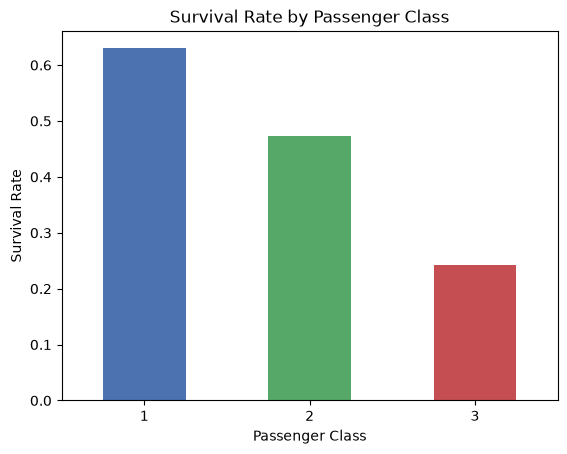

In [10]:
import matplotlib.pyplot as plt

summary_by_class["Survival Rate"].plot(kind="bar", color=["#4c72b0", "#55a868", "#c44e52"])
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.show()

---

## ✍️ Author

**Zayan Shawareb**
AI & ML Intern — BinX Tech
📅 Day 4 of Week 1 — Phase 1: Foundations

*This notebook is part of my ongoing learning journey through the BinX Tech AI/ML Internship Program.*